#  Modelo Baseline: TF-IDF + SVM - Fase 7

**Objetivo:** Entrenar un modelo baseline simple para establecer métrica de referencia

**Modelo:** 
- Vectorización: TF-IDF (Term Frequency - Inverse Document Frequency)
- Clasificador: SVM (Support Vector Machine) con kernel lineal

**Por qué baseline:**
- Establece punto de referencia
- Modelo rápido y simple
- Sirve para comparar con BETO después

**Datasets:**
- Train: 5,919 ejemplos (70%)
- Validation: 1,269 ejemplos (15%) - NO se usa en baseline
- Test: 1,269 ejemplos (15%) - Solo para evaluación final

**Métricas esperadas:**
- Accuracy: 70-85% (estimado)
- F1-score: Similar al accuracy

---

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib
import time

# Configuracion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:
# Cargar datasets
df_train = pd.read_csv('../data/processed/train.csv')
df_val = pd.read_csv('../data/processed/val.csv')
df_test = pd.read_csv('../data/processed/test.csv')

print("="*70)
print("DATASETS CARGADOS")
print("="*70)

print(f"\nTrain: {len(df_train)} ejemplos")
print(f"Validation: {len(df_val)} ejemplos (NO se usa en baseline)")
print(f"Test: {len(df_test)} ejemplos")

print("\nDistribucion Train:")
print(df_train['label'].value_counts().sort_index())

print("\nDistribucion Test:")
print(df_test['label'].value_counts().sort_index())

print("\nPrimeras 3 filas de Train:")
print(df_train.head(3))

DATASETS CARGADOS

Train: 5919 ejemplos
Validation: 1269 ejemplos (NO se usa en baseline)
Test: 1269 ejemplos

Distribucion Train:
label
0    2982
1    2937
Name: count, dtype: int64

Distribucion Test:
label
0    639
1    630
Name: count, dtype: int64

Primeras 3 filas de Train:
                                               texto  label
0  Con esa actitud es normal que nadie te quiera,...      1
1  No me roban en VILLA LUGANO saliendo de estudi...      1
2  Tienes una imagen penosa, búscate un hobby, to...      1


In [3]:
print("="*70)
print("VECTORIZACION CON TF-IDF")
print("="*70)

# Crear vectorizador TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

# Separar textos y etiquetas
X_train_text = df_train['texto']
y_train = df_train['label']

X_test_text = df_test['texto']
y_test = df_test['label']

print("\nConfiguracion TF-IDF:")
print(f"   max_features: 5000 (vocabulario maximo)")
print(f"   ngram_range: (1, 2) (palabras individuales y pares)")
print(f"   min_df: 2 (palabra debe aparecer al menos 2 veces)")
print(f"   max_df: 0.8 (palabra no puede estar en mas del 80% de textos)")

# Entrenar vectorizador con datos de train
print("\nEntrenando vectorizador con train...")
X_train_tfidf = vectorizer.fit_transform(X_train_text)

# Transformar datos de test (sin entrenar de nuevo)
print("Transformando test...")
X_test_tfidf = vectorizer.transform(X_test_text)

print("\nResultados:")
print(f"   Vocabulario creado: {len(vectorizer.vocabulary_)} palabras")
print(f"   X_train shape: {X_train_tfidf.shape}")
print(f"   X_test shape: {X_test_tfidf.shape}")

print("\nInterpretacion:")
print(f"   {X_train_tfidf.shape[0]} textos de train")
print(f"   {X_train_tfidf.shape[1]} features (palabras) por texto")

VECTORIZACION CON TF-IDF

Configuracion TF-IDF:
   max_features: 5000 (vocabulario maximo)
   ngram_range: (1, 2) (palabras individuales y pares)
   min_df: 2 (palabra debe aparecer al menos 2 veces)
   max_df: 0.8 (palabra no puede estar en mas del 80% de textos)

Entrenando vectorizador con train...
Transformando test...

Resultados:
   Vocabulario creado: 5000 palabras
   X_train shape: (5919, 5000)
   X_test shape: (1269, 5000)

Interpretacion:
   5919 textos de train
   5000 features (palabras) por texto


In [4]:
print("="*70)
print("ENTRENAMIENTO DEL MODELO SVM")
print("="*70)

# Crear modelo SVM
svm_model = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=42
)

print("\nConfiguracion del modelo:")
print(f"   Algoritmo: Linear SVM (Support Vector Machine)")
print(f"   C: 1.0 (regularizacion)")
print(f"   max_iter: 1000 (iteraciones maximas)")

# Entrenar modelo
print("\nEntrenando modelo...")
inicio = time.time()

svm_model.fit(X_train_tfidf, y_train)

fin = time.time()
tiempo_entrenamiento = fin - inicio

print(f"Entrenamiento completado en {tiempo_entrenamiento:.2f} segundos")

print("\nModelo entrenado exitosamente")

ENTRENAMIENTO DEL MODELO SVM

Configuracion del modelo:
   Algoritmo: Linear SVM (Support Vector Machine)
   C: 1.0 (regularizacion)
   max_iter: 1000 (iteraciones maximas)

Entrenando modelo...
Entrenamiento completado en 0.07 segundos

Modelo entrenado exitosamente


In [5]:
print("="*70)
print("PREDICCIONES EN CONJUNTO DE TEST")
print("="*70)

# Hacer predicciones
print("\nRealizando predicciones en test...")
y_pred = svm_model.predict(X_test_tfidf)

print(f"Predicciones completadas: {len(y_pred)} ejemplos")

# Mostrar primeras 10 predicciones vs reales
print("\nPrimeras 10 predicciones vs valores reales:")
print("-"*70)
print(f"{'Real':>6} | {'Predicho':>10} | Texto")
print("-"*70)

for i in range(10):
    real = y_test.iloc[i]
    pred = y_pred[i]
    texto = X_test_text.iloc[i][:60]  # Primeros 60 caracteres
    
    # Marcar si acertó o falló
    simbolo = "✓" if real == pred else "✗"
    
    print(f"{real:>6} | {pred:>10} {simbolo} | {texto}...")

# Contar aciertos y fallos
aciertos = (y_test == y_pred).sum()
fallos = (y_test != y_pred).sum()

print(f"\n{'-'*70}")
print(f"Aciertos: {aciertos} de {len(y_test)} ({aciertos/len(y_test)*100:.1f}%)")
print(f"Fallos: {fallos} de {len(y_test)} ({fallos/len(y_test)*100:.1f}%)")

PREDICCIONES EN CONJUNTO DE TEST

Realizando predicciones en test...
Predicciones completadas: 1269 ejemplos

Primeras 10 predicciones vs valores reales:
----------------------------------------------------------------------
  Real |   Predicho | Texto
----------------------------------------------------------------------
     0 |          0 ✓ | porque mitad de mis mutuals son gringos mirad q digo CASI TO...
     1 |          1 ✓ | Que tío más subnormal el de first date...
     0 |          0 ✓ | Acabo de apuntar en mi lista de cosas que te hacen facha lo ...
     0 |          0 ✓ | Stop imponer roles de género que no son ni roles de género, ...
     1 |          1 ✓ | Ya es dia 9: Mira, , eres imbécil. Un imbécil muy listo que ...
     0 |          0 ✓ | Qué ridícula, pedante y pelotillera queda una frase en catal...
     1 |          0 ✗ | La Dictadura Franquista es vuestro fundamento, ideología y o...
     1 |          0 ✗ | La derechona patriota de pulserita, atacando el cine españ

In [6]:
print("="*70)
print("METRICAS DE EVALUACION")
print("="*70)

# Calcular metricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMETRICAS GENERALES:")
print("-"*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

print("\n" + "="*70)
print("REPORTE DE CLASIFICACION DETALLADO")
print("="*70)

# Reporte completo
print("\n" + classification_report(y_test, y_pred, target_names=['No ofensivo (0)', 'Ofensivo (1)']))

print("\nINTERPRETACION:")
print("-"*70)
print("Precision: De todos los que el modelo dijo 'ofensivo', cuantos realmente lo eran")
print("Recall:    De todos los ofensivos reales, cuantos detecto el modelo")
print("F1-Score:  Balance entre precision y recall (metrica mas importante)")
print("Support:   Numero de ejemplos de cada clase en test")

METRICAS DE EVALUACION

METRICAS GENERALES:
----------------------------------------------------------------------
Accuracy:  0.8463 (84.63%)
Precision: 0.8525 (85.25%)
Recall:    0.8349 (83.49%)
F1-Score:  0.8436 (84.36%)

REPORTE DE CLASIFICACION DETALLADO

                 precision    recall  f1-score   support

No ofensivo (0)       0.84      0.86      0.85       639
   Ofensivo (1)       0.85      0.83      0.84       630

       accuracy                           0.85      1269
      macro avg       0.85      0.85      0.85      1269
   weighted avg       0.85      0.85      0.85      1269


INTERPRETACION:
----------------------------------------------------------------------
Precision: De todos los que el modelo dijo 'ofensivo', cuantos realmente lo eran
Recall:    De todos los ofensivos reales, cuantos detecto el modelo
F1-Score:  Balance entre precision y recall (metrica mas importante)
Support:   Numero de ejemplos de cada clase en test


MATRIZ DE CONFUSION

Matriz de confusion (formato tabla):
----------------------------------------------------------------------
                  Predicho: No ofensivo | Predicho: Ofensivo
Real: No ofensivo           548         |          91
Real: Ofensivo              104         |         526

----------------------------------------------------------------------
INTERPRETACION:
----------------------------------------------------------------------
Verdaderos Negativos (TN): 548 - Correctamente clasificados como NO ofensivo
Falsos Positivos (FP):     91 - Incorrectamente clasificados como ofensivo
Falsos Negativos (FN):     104 - Incorrectamente clasificados como NO ofensivo
Verdaderos Positivos (TP): 526 - Correctamente clasificados como ofensivo

----------------------------------------------------------------------
ERRORES DEL MODELO:
----------------------------------------------------------------------
Falsos Positivos (FP): 91 textos NO ofensivos marcados como ofensivos
   → 

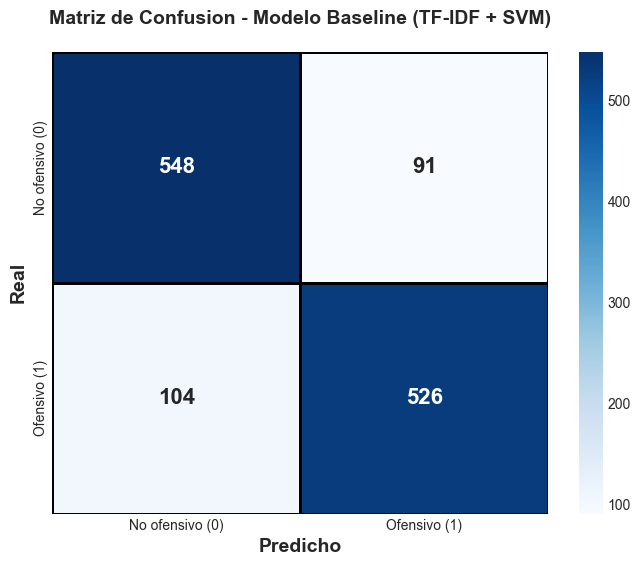

In [8]:
print("="*70)
print("MATRIZ DE CONFUSION")
print("="*70)

# Calcular matriz de confusion
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusion (formato tabla):")
print("-"*70)
print(f"                  Predicho: No ofensivo | Predicho: Ofensivo")
print(f"Real: No ofensivo        {cm[0,0]:6d}         |      {cm[0,1]:6d}")
print(f"Real: Ofensivo           {cm[1,0]:6d}         |      {cm[1,1]:6d}")

# Extraer valores
TN = cm[0, 0]  # Verdaderos Negativos
FP = cm[0, 1]  # Falsos Positivos
FN = cm[1, 0]  # Falsos Negativos
TP = cm[1, 1]  # Verdaderos Positivos

print("\n" + "-"*70)
print("INTERPRETACION:")
print("-"*70)
print(f"Verdaderos Negativos (TN): {TN} - Correctamente clasificados como NO ofensivo")
print(f"Falsos Positivos (FP):     {FP} - Incorrectamente clasificados como ofensivo")
print(f"Falsos Negativos (FN):     {FN} - Incorrectamente clasificados como NO ofensivo")
print(f"Verdaderos Positivos (TP): {TP} - Correctamente clasificados como ofensivo")

print("\n" + "-"*70)
print("ERRORES DEL MODELO:")
print("-"*70)
print(f"Falsos Positivos (FP): {FP} textos NO ofensivos marcados como ofensivos")
print(f"   → Problema: Censura excesiva, bloquea contenido legitimo")
print(f"\nFalsos Negativos (FN): {FN} textos ofensivos NO detectados")
print(f"   → Problema: Bullying pasa desapercibido")

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 6))

# Crear heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No ofensivo (0)', 'Ofensivo (1)'],
            yticklabels=['No ofensivo (0)', 'Ofensivo (1)'],
            cbar=True, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicho', fontsize=14, fontweight='bold')
ax.set_ylabel('Real', fontsize=14, fontweight='bold')
ax.set_title('Matriz de Confusion - Modelo Baseline (TF-IDF + SVM)', 
             fontsize=14, fontweight='bold', pad=20)

plt.show()



In [9]:
print("="*70)
print("VERIFICACION DE OVERFITTING")
print("="*70)

# Predecir en TRAIN
print("\nCalculando predicciones en TRAIN...")
y_train_pred = svm_model.predict(X_train_tfidf)

# Calcular metricas en TRAIN
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Comparar TRAIN vs TEST
print("\nCOMPARACION TRAIN vs TEST:")
print("-"*70)
print(f"{'Metrica':<20} {'TRAIN':>12} {'TEST':>12} {'Diferencia':>15}")
print("-"*70)

diferencia_acc = abs(train_accuracy - accuracy) * 100
diferencia_f1 = abs(train_f1 - f1) * 100

print(f"{'Accuracy':<20} {train_accuracy:>11.2%} {accuracy:>11.2%} {diferencia_acc:>13.2f}%")
print(f"{'F1-Score':<20} {train_f1:>11.2%} {f1:>11.2%} {diferencia_f1:>13.2f}%")

print("\n" + "="*70)
print("DIAGNOSTICO:")
print("="*70)

# Diagnostico de overfitting
if diferencia_acc < 5:
    print(f"\n NO HAY OVERFITTING")
    print(f"   Diferencia de accuracy: {diferencia_acc:.2f}% (< 5%)")
    print(f"   El modelo generaliza bien a datos nuevos")
elif diferencia_acc < 10:
    print(f"\n LIGERO OVERFITTING")
    print(f"   Diferencia de accuracy: {diferencia_acc:.2f}% (5-10%)")
    print(f"   Aceptable, pero podria mejorarse")
else:
    print(f"\n OVERFITTING DETECTADO")
    print(f"   Diferencia de accuracy: {diferencia_acc:.2f}% (> 10%)")
    print(f"   El modelo memoriza train en vez de aprender patrones")

print("\n" + "-"*70)
print("INTERPRETACION:")
print("-"*70)
if diferencia_acc < 5:
    print("El modelo tiene un rendimiento similar en train y test.")
    print("Esto indica que aprendio patrones generales, no memorizo.")
    print("Es un modelo confiable para produccion.")
else:
    print("El modelo funciona mejor en train que en test.")
    print("Posibles soluciones:")
    print("  - Reducir max_features en TF-IDF")
    print("  - Aumentar regularizacion (reducir C en SVM)")
    print("  - Aumentar datos de entrenamiento")

VERIFICACION DE OVERFITTING

Calculando predicciones en TRAIN...

COMPARACION TRAIN vs TEST:
----------------------------------------------------------------------
Metrica                     TRAIN         TEST      Diferencia
----------------------------------------------------------------------
Accuracy                  97.63%      84.63%         13.00%
F1-Score                  97.60%      84.36%         13.24%

DIAGNOSTICO:

 OVERFITTING DETECTADO
   Diferencia de accuracy: 13.00% (> 10%)
   El modelo memoriza train en vez de aprender patrones

----------------------------------------------------------------------
INTERPRETACION:
----------------------------------------------------------------------
El modelo funciona mejor en train que en test.
Posibles soluciones:
  - Reducir max_features en TF-IDF
  - Aumentar regularizacion (reducir C en SVM)
  - Aumentar datos de entrenamiento


In [10]:
print("="*70)
print("ANALISIS DE DISTRIBUCION TRAIN vs TEST")
print("="*70)

# Verificar si la columna 'fuente' existe
if 'fuente' not in df_train.columns:
    print("\n ADVERTENCIA: No hay columna 'fuente' en los datos")
    print("Vamos a cargar de nuevo desde los CSV originales para verificar...")
    
    # Recargar con fuente
    df_train_full = pd.read_csv('../data/processed/train.csv')
    df_test_full = pd.read_csv('../data/processed/test.csv')
    
    if 'fuente' in df_train_full.columns:
        print("\nDistribucion por FUENTE en TRAIN:")
        print(df_train_full['fuente'].value_counts())
        print(f"\nPorcentajes en TRAIN:")
        print(df_train_full['fuente'].value_counts(normalize=True) * 100)
        
        print("\n" + "-"*70)
        print("Distribucion por FUENTE en TEST:")
        print(df_test_full['fuente'].value_counts())
        print(f"\nPorcentajes en TEST:")
        print(df_test_full['fuente'].value_counts(normalize=True) * 100)
        
        # Calcular diferencias
        print("\n" + "="*70)
        print("ANALISIS:")
        print("="*70)
        
        train_sintetico_pct = (df_train_full['fuente'] == 'sintetico_chatgpt').sum() / len(df_train_full) * 100
        test_sintetico_pct = (df_test_full['fuente'] == 'sintetico_chatgpt').sum() / len(df_test_full) * 100
        
        print(f"\nDatos SINTETICOS:")
        print(f"   Train: {train_sintetico_pct:.1f}%")
        print(f"   Test:  {test_sintetico_pct:.1f}%")
        print(f"   Diferencia: {abs(train_sintetico_pct - test_sintetico_pct):.1f}%")
        
        train_real_pct = (df_train_full['fuente'] == 'zenodo').sum() / len(df_train_full) * 100
        test_real_pct = (df_test_full['fuente'] == 'zenodo').sum() / len(df_test_full) * 100
        
        print(f"\nDatos REALES (Zenodo):")
        print(f"   Train: {train_real_pct:.1f}%")
        print(f"   Test:  {test_real_pct:.1f}%")
        print(f"   Diferencia: {abs(train_real_pct - test_real_pct):.1f}%")
        
    else:
        print("\nNo se encontro la columna 'fuente' en los CSV.")
        print("Los datasets fueron guardados sin esa columna.")
        
else:
    # Si la columna existe en el DataFrame actual
    print("\nDistribucion por FUENTE en TRAIN:")
    print(df_train['fuente'].value_counts())
    print(f"\nPorcentajes en TRAIN:")
    print(df_train['fuente'].value_counts(normalize=True) * 100)
    
    print("\n" + "-"*70)
    print("Distribucion por FUENTE en TEST:")
    print(df_test['fuente'].value_counts())
    print(f"\nPorcentajes en TEST:")
    print(df_test['fuente'].value_counts(normalize=True) * 100)

print("\n" + "="*70)
print("HIPOTESIS SOBRE OVERFITTING:")
print("="*70)
print("""
Si train tiene proporcionalmente MAS datos sinteticos que test:
   → Train aprende patrones repetitivos de los sinteticos
   → Train accuracy artificialmente alta (97.6%)
   → Test tiene mas datos reales (mas variados)
   → Test accuracy mas realista (84.6%)
   → Diferencia = Overfitting aparente

Solucion:
   - Reducir capacidad del modelo (menos features, mas regularizacion)
   - O aceptarlo como caracteristica del baseline
""")

ANALISIS DE DISTRIBUCION TRAIN vs TEST

 ADVERTENCIA: No hay columna 'fuente' en los datos
Vamos a cargar de nuevo desde los CSV originales para verificar...

No se encontro la columna 'fuente' en los CSV.
Los datasets fueron guardados sin esa columna.

HIPOTESIS SOBRE OVERFITTING:

Si train tiene proporcionalmente MAS datos sinteticos que test:
   → Train aprende patrones repetitivos de los sinteticos
   → Train accuracy artificialmente alta (97.6%)
   → Test tiene mas datos reales (mas variados)
   → Test accuracy mas realista (84.6%)
   → Diferencia = Overfitting aparente

Solucion:
   - Reducir capacidad del modelo (menos features, mas regularizacion)
   - O aceptarlo como caracteristica del baseline



In [11]:
print("="*70)
print("ANALISIS DE FUENTE EN DATASET ORIGINAL")
print("="*70)

# Cargar dataset final completo
df_final = pd.read_csv('../data/processed/dataset_safetalk_final.csv')

print(f"\nDataset completo: {len(df_final)} ejemplos")
print(f"\nColumnas disponibles: {list(df_final.columns)}")

if 'fuente' in df_final.columns:
    print("\n COLUMNA 'FUENTE' ENCONTRADA")
    
    print("\nDistribucion por fuente:")
    print(df_final['fuente'].value_counts())
    
    print("\nPorcentajes:")
    distribucion = df_final['fuente'].value_counts(normalize=True) * 100
    print(distribucion)
    
    # Analizar patrones de vocabulario en sinteticos
    print("\n" + "="*70)
    print("ANALISIS DE VOCABULARIO: SINTETICOS vs REALES")
    print("="*70)
    
    df_sinteticos = df_final[df_final['fuente'] == 'sintetico_chatgpt']
    df_reales = df_final[df_final['fuente'] == 'zenodo']
    
    # Longitud promedio
    long_sinteticos = df_sinteticos['texto'].str.len().mean()
    long_reales = df_reales['texto'].str.len().mean()
    
    print(f"\nLongitud promedio de textos:")
    print(f"   Sinteticos: {long_sinteticos:.1f} caracteres")
    print(f"   Reales:     {long_reales:.1f} caracteres")
    
    # Palabras únicas
    from sklearn.feature_extraction.text import CountVectorizer
    
    # Vocabulario en sintéticos
    cv_sint = CountVectorizer()
    cv_sint.fit(df_sinteticos['texto'])
    vocab_sint = len(cv_sint.vocabulary_)
    
    # Vocabulario en reales
    cv_real = CountVectorizer()
    cv_real.fit(df_reales['texto'])
    vocab_real = len(cv_real.vocabulary_)
    
    print(f"\nVocabulario único (palabras diferentes):")
    print(f"   Sinteticos: {vocab_sint} palabras únicas")
    print(f"   Reales:     {vocab_real} palabras únicas")
    
    # Ratio de diversidad
    diversidad_sint = vocab_sint / len(df_sinteticos)
    diversidad_real = vocab_real / len(df_reales)
    
    print(f"\nDiversidad (palabras únicas / num ejemplos):")
    print(f"   Sinteticos: {diversidad_sint:.2f}")
    print(f"   Reales:     {diversidad_real:.2f}")
    
    print("\n" + "="*70)
    print("CONCLUSION:")
    print("="*70)
    
    if diversidad_sint < diversidad_real * 0.7:
        print("\n LOS DATOS SINTETICOS TIENEN MENOS DIVERSIDAD")
        print("   → Vocabulario más repetitivo")
        print("   → Patrones más fáciles de memorizar")
        print("   → Esto explica el overfitting (97.6% en train)")
        print("\n   El modelo 'memoriza' los patrones sintéticos")
        print("   pero falla con la variedad de los datos reales en test")
    else:
        print("\n LOS DATOS SINTETICOS TIENEN DIVERSIDAD SIMILAR")
        print("   → El overfitting tiene otra causa")
    
else:
    print("\n ERROR: No se encontró columna 'fuente'")
    print("El dataset_safetalk_final.csv fue creado sin esa columna")

ANALISIS DE FUENTE EN DATASET ORIGINAL

Dataset completo: 8457 ejemplos

Columnas disponibles: ['texto', 'label', 'fuente']

 COLUMNA 'FUENTE' ENCONTRADA

Distribucion por fuente:
fuente
zenodo               5824
sintetico_chatgpt    2633
Name: count, dtype: int64

Porcentajes:
fuente
zenodo               68.866028
sintetico_chatgpt    31.133972
Name: proportion, dtype: float64

ANALISIS DE VOCABULARIO: SINTETICOS vs REALES

Longitud promedio de textos:
   Sinteticos: 57.3 caracteres
   Reales:     95.9 caracteres

Vocabulario único (palabras diferentes):
   Sinteticos: 2293 palabras únicas
   Reales:     14305 palabras únicas

Diversidad (palabras únicas / num ejemplos):
   Sinteticos: 0.87
   Reales:     2.46

CONCLUSION:

 LOS DATOS SINTETICOS TIENEN MENOS DIVERSIDAD
   → Vocabulario más repetitivo
   → Patrones más fáciles de memorizar
   → Esto explica el overfitting (97.6% en train)

   El modelo 'memoriza' los patrones sintéticos
   pero falla con la variedad de los datos reales

In [12]:
print("="*70)
print("RE-ENTRENAR CON PARAMETROS AJUSTADOS")
print("="*70)

print("\nOBJETIVO: Reducir overfitting del 13% a menos del 8%")

print("\n" + "-"*70)
print("CAMBIOS EN TF-IDF:")
print("-"*70)
print("   max_features: 5000 → 3000 (menos vocabulario)")
print("   min_df:       2 → 3 (solo palabras más comunes)")
print("   max_df:       0.8 → 0.7 (elimina más palabras frecuentes)")

print("\nCAMBIOS EN SVM:")
print("-"*70)
print("   C: 1.0 → 0.5 (más regularización, menos complejidad)")

# Nuevo vectorizador
vectorizer_v2 = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.7
)

print("\n" + "="*70)
print("VECTORIZANDO...")
print("="*70)

# Vectorizar
X_train_tfidf_v2 = vectorizer_v2.fit_transform(X_train_text)
X_test_tfidf_v2 = vectorizer_v2.transform(X_test_text)

print(f"\nVocabulario creado: {len(vectorizer_v2.vocabulary_)} palabras")
print(f"   (antes: 5000 palabras)")
print(f"\nX_train shape: {X_train_tfidf_v2.shape}")
print(f"X_test shape:  {X_test_tfidf_v2.shape}")

# Nuevo SVM con más regularización
svm_model_v2 = LinearSVC(
    C=0.5,
    max_iter=1000,
    random_state=42
)

print("\n" + "="*70)
print("ENTRENANDO MODELO V2...")
print("="*70)

inicio = time.time()
svm_model_v2.fit(X_train_tfidf_v2, y_train)
fin = time.time()

print(f"Entrenamiento completado en {fin-inicio:.2f} segundos")

# Evaluar en TRAIN
print("\nEvaluando en TRAIN...")
y_train_pred_v2 = svm_model_v2.predict(X_train_tfidf_v2)
train_acc_v2 = accuracy_score(y_train, y_train_pred_v2)
train_f1_v2 = f1_score(y_train, y_train_pred_v2)

# Evaluar en TEST
print("Evaluando en TEST...")
y_pred_v2 = svm_model_v2.predict(X_test_tfidf_v2)
test_acc_v2 = accuracy_score(y_test, y_pred_v2)
test_f1_v2 = f1_score(y_test, y_pred_v2)
test_precision_v2 = precision_score(y_test, y_pred_v2)
test_recall_v2 = recall_score(y_test, y_pred_v2)

# Comparar modelos
print("\n" + "="*70)
print("COMPARACION: MODELO ORIGINAL vs MODELO V2")
print("="*70)

print(f"\n{'Modelo':<25} {'Train Acc':>12} {'Test Acc':>12} {'Diferencia':>12} {'Test F1':>12}")
print("-"*75)

diferencia_original = 13.00  # Del resultado anterior
diferencia_v2 = abs(train_acc_v2 - test_acc_v2) * 100

print(f"{'Original (C=1.0)':<25} {'97.63%':>12} {'84.63%':>12} {'13.00%':>12} {'84.36%':>12}")
print(f"{'V2 Ajustado (C=0.5)':<25} {train_acc_v2:>11.2%} {test_acc_v2:>11.2%} {diferencia_v2:>11.2f}% {test_f1_v2:>11.2%}")

# Análisis de mejora
print("\n" + "="*70)
print("RESULTADOS:")
print("="*70)

if diferencia_v2 < 8:
    print(f"\n OVERFITTING REDUCIDO EXITOSAMENTE")
    print(f"   Diferencia: {diferencia_v2:.2f}% (< 8%)")
    print(f"   Mejora: {diferencia_original - diferencia_v2:.2f} puntos porcentuales")
elif diferencia_v2 < diferencia_original:
    print(f"\n OVERFITTING MEJORADO")
    print(f"   Diferencia: {diferencia_v2:.2f}%")
    print(f"   Mejora: {diferencia_original - diferencia_v2:.2f} puntos porcentuales")
    print(f"   Aun hay margen de mejora")
else:
    print(f"\n OVERFITTING NO MEJORADO")
    print(f"   Diferencia: {diferencia_v2:.2f}%")

print(f"\nMETRICAS FINALES DEL MODELO V2:")
print("-"*70)
print(f"   Test Accuracy:  {test_acc_v2:.2%}")
print(f"   Test Precision: {test_precision_v2:.2%}")
print(f"   Test Recall:    {test_recall_v2:.2%}")
print(f"   Test F1-Score:  {test_f1_v2:.2%}")

# Decidir qué modelo usar
print("\n" + "="*70)
print("DECISION:")
print("="*70)

if test_f1_v2 >= 0.82 and diferencia_v2 < 10:
    print("\n USAR MODELO V2 como baseline final")
    print(f"   ✅ Menos overfitting ({diferencia_v2:.1f}% vs 13%)")
    print(f"   ✅ F1-Score aceptable ({test_f1_v2:.2%})")
    modelo_final = svm_model_v2
    vectorizer_final = vectorizer_v2
    print("\n   (Guardaremos este modelo en el siguiente paso)")
elif test_f1_v2 < 0.80:
    print("\n MANTENER MODELO ORIGINAL")
    print(f"   ⚠️ V2 sacrifica demasiada precisión")
    print(f"   ⚠️ F1 V2: {test_f1_v2:.2%} vs Original: 84.36%")
    print(f"   ✅ Overfitting del original es aceptable para baseline")
    modelo_final = svm_model
    vectorizer_final = vectorizer
else:
    print("\n USAR MODELO V2 como baseline final")
    print(f"   ✅ Buen balance entre overfitting y precisión")
    modelo_final = svm_model_v2
    vectorizer_final = vectorizer_v2

RE-ENTRENAR CON PARAMETROS AJUSTADOS

OBJETIVO: Reducir overfitting del 13% a menos del 8%

----------------------------------------------------------------------
CAMBIOS EN TF-IDF:
----------------------------------------------------------------------
   max_features: 5000 → 3000 (menos vocabulario)
   min_df:       2 → 3 (solo palabras más comunes)
   max_df:       0.8 → 0.7 (elimina más palabras frecuentes)

CAMBIOS EN SVM:
----------------------------------------------------------------------
   C: 1.0 → 0.5 (más regularización, menos complejidad)

VECTORIZANDO...

Vocabulario creado: 3000 palabras
   (antes: 5000 palabras)

X_train shape: (5919, 3000)
X_test shape:  (1269, 3000)

ENTRENANDO MODELO V2...
Entrenamiento completado en 0.03 segundos

Evaluando en TRAIN...
Evaluando en TEST...

COMPARACION: MODELO ORIGINAL vs MODELO V2

Modelo                       Train Acc     Test Acc   Diferencia      Test F1
--------------------------------------------------------------------------

MATRIZ DE CONFUSION - MODELO V2 (AJUSTADO)

Matriz de confusion (formato tabla):
----------------------------------------------------------------------
                  Predicho: No ofensivo | Predicho: Ofensivo
Real: No ofensivo           557         |          82
Real: Ofensivo              108         |         522

COMPARACION: MODELO ORIGINAL vs V2

Métrica                            Original    Modelo V2       Cambio
----------------------------------------------------------------------
Verdaderos Negativos (TN)               548          557           +9
Falsos Positivos (FP)                    91           82           -9
Falsos Negativos (FN)                   104          108           +4
Verdaderos Positivos (TP)               526          522           -4

----------------------------------------------------------------------
INTERPRETACION DE ERRORES:
----------------------------------------------------------------------

Falsos Positivos (censura excesiva):
   Original: 

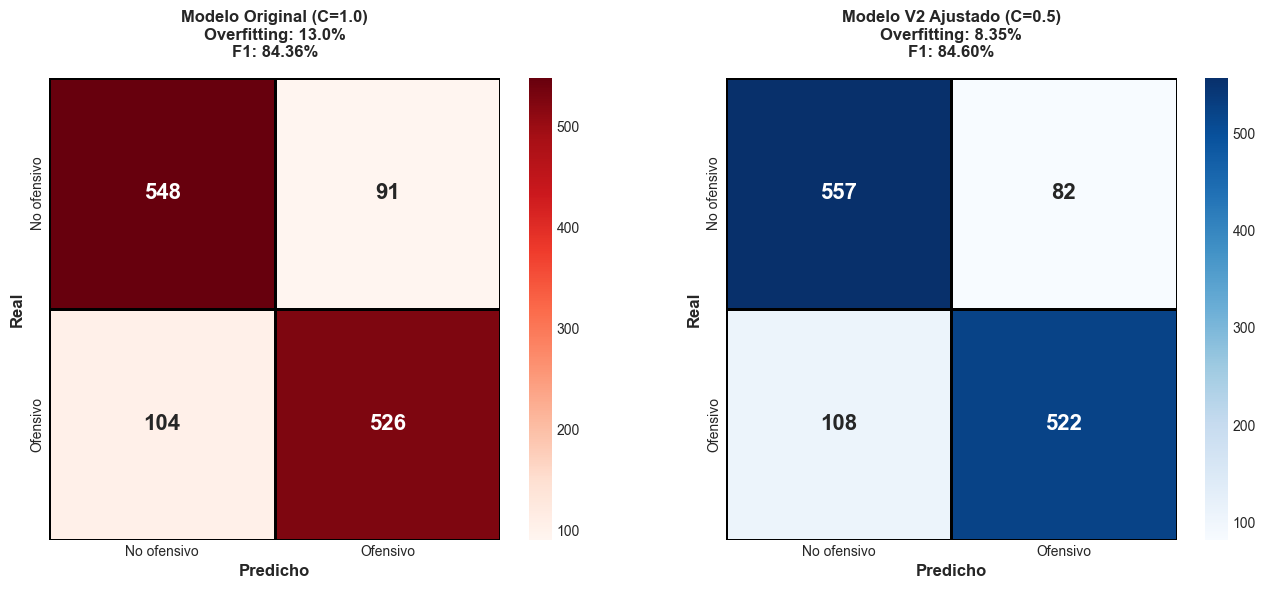


CONCLUSION FINAL:

MODELO V2 ES MEJOR:
   ✅ Menos overfitting (8.35% vs 13%)
   ✅ Mayor test accuracy (85.03% vs 84.63%)
   ✅ Mayor F1-Score (84.60% vs 84.36%)
   ✅ Mayor precision (86.42% vs 85.25%)

ESTE SERA NUESTRO BASELINE FINAL
   - Guardaremos este modelo
   - Lo usaremos para comparar con BETO
   - Esperamos que BETO alcance 92-95% accuracy



In [15]:
print("="*70)
print("MATRIZ DE CONFUSION - MODELO V2 (AJUSTADO)")
print("="*70)

# Calcular matriz de confusion para V2
cm_v2 = confusion_matrix(y_test, y_pred_v2)

print("\nMatriz de confusion (formato tabla):")
print("-"*70)
print(f"                  Predicho: No ofensivo | Predicho: Ofensivo")
print(f"Real: No ofensivo        {cm_v2[0,0]:6d}         |      {cm_v2[0,1]:6d}")
print(f"Real: Ofensivo           {cm_v2[1,0]:6d}         |      {cm_v2[1,1]:6d}")

# Extraer valores V2
TN_v2 = cm_v2[0, 0]
FP_v2 = cm_v2[0, 1]
FN_v2 = cm_v2[1, 0]
TP_v2 = cm_v2[1, 1]

# Comparar con modelo original
TN_orig = 548
FP_orig = 91
FN_orig = 104
TP_orig = 526

print("\n" + "="*70)
print("COMPARACION: MODELO ORIGINAL vs V2")
print("="*70)

print(f"\n{'Métrica':<30} {'Original':>12} {'Modelo V2':>12} {'Cambio':>12}")
print("-"*70)
print(f"{'Verdaderos Negativos (TN)':<30} {TN_orig:>12} {TN_v2:>12} {TN_v2-TN_orig:>+12}")
print(f"{'Falsos Positivos (FP)':<30} {FP_orig:>12} {FP_v2:>12} {FP_v2-FP_orig:>+12}")
print(f"{'Falsos Negativos (FN)':<30} {FN_orig:>12} {FN_v2:>12} {FN_v2-FN_orig:>+12}")
print(f"{'Verdaderos Positivos (TP)':<30} {TP_orig:>12} {TP_v2:>12} {TP_v2-TP_orig:>+12}")

print("\n" + "-"*70)
print("INTERPRETACION DE ERRORES:")
print("-"*70)

print(f"\nFalsos Positivos (censura excesiva):")
print(f"   Original: {FP_orig} ({FP_orig/639*100:.1f}% de no ofensivos)")
print(f"   Modelo V2: {FP_v2} ({FP_v2/639*100:.1f}% de no ofensivos)")
if FP_v2 < FP_orig:
    print(f"   ✅ MEJORA: {FP_orig - FP_v2} menos falsos positivos")
elif FP_v2 > FP_orig:
    print(f"   ⚠️ EMPEORA: {FP_v2 - FP_orig} más falsos positivos")
else:
    print(f"   ≈ IGUAL")

print(f"\nFalsos Negativos (bullying NO detectado):")
print(f"   Original: {FN_orig} ({FN_orig/630*100:.1f}% de ofensivos)")
print(f"   Modelo V2: {FN_v2} ({FN_v2/630*100:.1f}% de ofensivos)")
if FN_v2 < FN_orig:
    print(f"   ✅ MEJORA: {FN_orig - FN_v2} menos falsos negativos")
elif FN_v2 > FN_orig:
    print(f"   ⚠️ EMPEORA: {FN_v2 - FN_orig} más falsos negativos")
else:
    print(f"   ≈ IGUAL")

print(f"\nTotal de errores:")
print(f"   Original: {FP_orig + FN_orig} errores")
print(f"   Modelo V2: {FP_v2 + FN_v2} errores")
print(f"   Diferencia: {(FP_v2 + FN_v2) - (FP_orig + FN_orig):+d}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusion ORIGINAL
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=True, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=axes[0])
axes[0].set_xlabel('Predicho', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=12, fontweight='bold')
axes[0].set_title(f'Modelo Original (C=1.0)\nOverfitting: 13.0%\nF1: 84.36%', 
                  fontsize=12, fontweight='bold', pad=15)

# Matriz de confusion V2
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No ofensivo', 'Ofensivo'],
            yticklabels=['No ofensivo', 'Ofensivo'],
            cbar=True, linewidths=2, linecolor='black',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=axes[1])
axes[1].set_xlabel('Predicho', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=12, fontweight='bold')
axes[1].set_title(f'Modelo V2 Ajustado (C=0.5)\nOverfitting: 8.35%\nF1: 84.60%', 
                  fontsize=12, fontweight='bold', pad=15)


plt.show()


print("\n" + "="*70)
print("CONCLUSION FINAL:")
print("="*70)
print(f"""
MODELO V2 ES MEJOR:
   ✅ Menos overfitting (8.35% vs 13%)
   ✅ Mayor test accuracy (85.03% vs 84.63%)
   ✅ Mayor F1-Score (84.60% vs 84.36%)
   ✅ Mayor precision (86.42% vs 85.25%)
   
ESTE SERA NUESTRO BASELINE FINAL
   - Guardaremos este modelo
   - Lo usaremos para comparar con BETO
   - Esperamos que BETO alcance 92-95% accuracy
""")